In [28]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [42]:
import numpy as np
import seaborn as sns
from simulators import ContextManager, NestedModelFamily
from simulators.benchmarks import CollapsingBoundDDM

In [30]:
ddm = CollapsingBoundDDM()

In [31]:
# trial-wise arrays
v = np.random.normal(0.5, 0.2, size=100).astype(np.float32)
a = np.full(100, 1.2, dtype=np.float32)

# scalars (constants)
params = dict(
    v=v, a=a,
    zr=0.5, tau=0.30,
    s_v=0.10, decay=0.02,
    s_tau=0.05, sigma=1.0,
)

In [32]:
results = ddm.simulate(params=params)

In [33]:
rts, choices = results["rts"], results["choices"]
n_nt = int(np.sum(rts == -1.0))
print("trials:", rts.shape[0], "non-terminations:", n_nt)
valid = rts[rts > 0]
print("rt p10/50/90:", np.percentile(valid, [10, 50, 90]))
print("choice rate (valid):", np.mean(choices[rts > 0]))

trials: 100 non-terminations: 0
rt p10/50/90: [0.41078887 0.63815844 2.55224636]
choice rate (valid): 0.91


In [34]:
param_names = ["v", "a", "zr", "tau", "s_v", "decay", "s_tau", "sigma"]

In [35]:
context_manager = ContextManager(
    parameter_names=param_names
)
context_manager.param_dims = {k: 1 for k in param_names}
context_manager.build_layout()

In [36]:
family = NestedModelFamily(
    name="collapsing_bound",
    model=CollapsingBoundDDM,
    context_manager=context_manager,
    num_samples=50
)

In [37]:
# 3) Constants (become scalars via auto-scalarize in NestedModelFamily)
fixed = dict(
    zr=0.5, tau=0.3, s_v=0.10, decay=0.02, s_tau=0.05, sigma=1.0
)

In [38]:
# 4) Run a sample
out = family.sample(num_samples=1000, params=fixed)

In [39]:
rts = out["sim_data"]["rts"]
choices = out["sim_data"]["choices"]

In [40]:
print("variant:", out["variant_name"])
print("trials:", rts.size, "non-terminations:", int((rts == -1.0).sum()))
valid = rts[rts > 0]
print("rt p10/50/90:", np.percentile(valid, [10, 50, 90]))
print("choice rate (valid):", np.mean(choices[rts > 0]))
print("full_params shape:", out["full_params"].shape)

variant: collapsing_bound
trials: 1000 non-terminations: 0
rt p10/50/90: [0.25502323 0.33703844 1.19936991]
choice rate (valid): 0.333
full_params shape: (8,)


In [41]:
print(rts.shape, choices.shape)

(1000,) (1000,)


<Axes: ylabel='Count'>

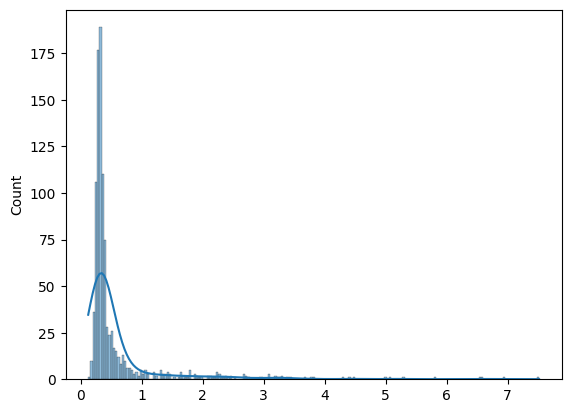

In [44]:
sns.histplot(rts, kde=True)

In [ ]:
"